# Proyecto Integrador de Aprendizaje Automático

El crecimiento de las plataformas de préstamos en línea ha generado grandes volúmenes de datos financieros y socioeconómicos que representan una oportunidad para aplicar técnicas de aprendizaje automático en la predicción del riesgo crediticio. Con la plataforma de Lending Club nos proporciona un extenso conjunto de información histórica sobre los préstamos emitidos entre 2007 y 2020, al igual que variables relacionadas con el perfil del que solicita, condiciones del crédito y su estado.

El presente proyecto tiene como objetivo construir un modelo de clasificación supervisada capaz de predecir si un préstamo será pagado en su totalidad o entrará en incumplimiento. Por eso, se comparan dos enfoques: scikit-learn y con PySpark. Evaluando el rendimiento de ambos como métricas de clasificación y tiempos de ejecusión, junto con la técnica LIME para interpretar los resultados.

Para ello, iniciamos importando las librerias que necesitamos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge, Lasso, LogisticRegression, LinearRegression
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             confusion_matrix, classification_report, roc_auc_score, roc_curve)
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

Leemos nuestro dataset sugerido

In [2]:
dataset = pd.read_csv('accepted_2007_to_2018Q4.csv.gz', sep=',')

C:\Users\Administrador\AppData\Local\Temp\ipykernel_6276\145429866.py:1: DtypeWarning: Columns (0,19,49,59,118,129,130,131,134,135,136,139,145,146,147) have mixed types. Specify dtype option on import or set low_memory=False.
  dataset = pd.read_csv('accepted_2007_to_2018Q4.csv.gz', sep=',')


El tamaño de nuestro dataset:

In [3]:
print("Dimensiones:", dataset.shape)

Dimensiones: (2260701, 151)


Revisamos las primeras 5 filas del dataset:

In [4]:
dataset.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


Las 5 últimas filas:

In [5]:
dataset.tail()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
2260696,88985880,NaN,40000.0,40000.0,40000.0,60 months,10.49,859.56,B,B3,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2260697,88224441,NaN,24000.0,24000.0,24000.0,60 months,14.49,564.56,C,C4,...,NaN,NaN,Cash,Y,Mar-2019,ACTIVE,Mar-2019,10000.0,44.82,1.0
2260698,88215728,NaN,14000.0,14000.0,14000.0,60 months,14.49,329.33,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2260699,Total amount funded in policy code 1: 1465324575,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2260700,Total amount funded in policy code 2: 521953170,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Vemos que siguen en orden la información. Ahora vemos la naturaleza de los datos:

In [6]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Columns: 151 entries, id to settlement_term
dtypes: float64(113), object(38)
memory usage: 2.5+ GB


Vemos que hay 113 variables numéricas y 38 variables categóricas. Aplicando esta función vemos que puede haber presencia de datos faltantes, por ello vamos a ver en qué variables se están presentando dichos faltantes.

In [7]:
dataset.describe()

,member_id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,delinq_2yrs,fico_range_low,...,deferral_term,hardship_amount,hardship_length,hardship_dpd,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,settlement_amount,settlement_percentage,settlement_term
count,0.0,2.260668e+06,2.260668e+06,2.260668e+06,2.260668e+06,2.260668e+06,2.260664e+06,2.258957e+06,2.260639e+06,2.260668e+06,...,10917.0,10917.000000,10917.0,10917.000000,8651.000000,10917.000000,10917.000000,34246.000000,34246.000000,34246.000000
mean,NaN,1.504693e+04,1.504166e+04,1.502344e+04,1.309283e+01,4.458068e+02,7.799243e+04,1.882420e+01,3.068792e-01,6.985882e+02,...,3.0,155.045981,3.0,13.743886,454.798089,11636.883942,193.994321,5010.664267,47.780365,13.191322
std,NaN,9.190245e+03,9.188413e+03,9.192332e+03,4.832138e+00,2.671735e+02,1.126962e+05,1.418333e+01,8.672303e-01,3.301038e+01,...,0.0,129.040594,0.0,9.671178,375.385500,7625.988281,198.629496,3693.122590,7.311822,8.159980
min,NaN,5.000000e+02,5.000000e+02,0.000000e+00,5.310000e+00,4.930000e+00,0.000000e+00,-1.000000e+00,0.000000e+00,6.100000e+02,...,3.0,0.640000,3.0,0.000000,1.920000,55.730000,0.010000,44.210000,0.200000,0.000000
25%,NaN,8.000000e+03,8.000000e+03,8.000000e+03,9.490000e+00,2.516500e+02,4.600000e+04,1.189000e+01,0.000000e+00,6.750000e+02,...,3.0,59.440000,3.0,5.000000,175.230000,5627.000000,44.440000,2208.000000,45.000000,6.000000
50%,NaN,1.290000e+04,1.287500e+04,1.280000e+04,1.262000e+01,3.779900e+02,6.500000e+04,1.784000e+01,0.000000e+00,6.900000e+02,...,3.0,119.140000,3.0,15.000000,352.770000,10028.390000,133.160000,4146.110000,45.000000,14.000000
75%,NaN,2.000000e+04,2.000000e+04,2.000000e+04,1.599000e+01,5.933200e+02,9.300000e+04,2.449000e+01,0.000000e+00,7.150000e+02,...,3.0,213.260000,3.0,22.000000,620.175000,16151.890000,284.190000,6850.172500,50.000000,18.000000
max,NaN,4.000000e+04,4.000000e+04,4.000000e+04,3.099000e+01,1.719830e+03,1.100000e+08,9.990000e+02,5.800000e+01,8.450000e+02,...,3.0,943.940000,3.0,37.000000,2680.890000,40306.410000,1407.860000,33601.000000,521.350000,181.000000


In [8]:
dataset.isnull().sum()

id                             0
member_id                2260701
loan_amnt                     33
funded_amnt                   33
funded_amnt_inv               33
                          ...   
settlement_status        2226455
settlement_date          2226455
settlement_amount        2226455
settlement_percentage    2226455
settlement_term          2226455
Length: 151, dtype: int64

In [12]:
total_registros = len(dataset)
faltantes_por_columna = dataset.isnull().sum()
porcentaje_faltantes = (faltantes_por_columna / total_registros) * 100

analisis_faltantes = pd.DataFrame({
    'Valores_Faltantes': faltantes_por_columna,
    'Porcentaje_Faltantes': porcentaje_faltantes
})

print("=== Análisis de faltantes por variable ===")
print(analisis_faltantes.sort_values('Porcentaje_Faltantes', ascending=False))

# Clasificación de variables según % de faltantes
variables_eliminar_faltantes = analisis_faltantes[analisis_faltantes['Porcentaje_Faltantes'] > 50].index.tolist()
variables_imputar = analisis_faltantes[(analisis_faltantes['Porcentaje_Faltantes'] > 0) & 
                                       (analisis_faltantes['Porcentaje_Faltantes'] <= 50)].index.tolist()
variables_limpias = analisis_faltantes[analisis_faltantes['Porcentaje_Faltantes'] == 0].index.tolist()

print("\n=== Variables con >50% faltantes (eliminar) ===")
print(variables_eliminar_faltantes)

print("\n=== Variables con 0–50% faltantes (imputar) ===")
print(variables_imputar)

print("\n=== Variables sin faltantes (limpias) ===")
print(variables_limpias)

# Eliminar variables con >50% de faltantes
dataset = dataset.drop(columns=variables_eliminar_faltantes)
print(f"\nNuevo shape después de eliminar columnas: {dataset.shape}")


=== Análisis de faltantes por variable ===
                                            Valores_Faltantes  \
member_id                                             2260701   
orig_projected_additional_accrued_interest            2252050   
hardship_reason                                       2249784   
hardship_payoff_balance_amount                        2249784   
hardship_last_payment_amount                          2249784   
...                                                       ...   
total_rec_int                                              33   
disbursement_method                                        33   
hardship_flag                                              33   
debt_settlement_flag                                       33   
id                                                          0   

                                            Porcentaje_Faltantes  
member_id                                             100.000000  
orig_projected_additional_accrued_interest

Con las variables identificadas según su porcentaje de datos faltantes, empezamos con el tratamiento:

Primero, estudiamos las variables que para nuestro estudio pueden ser irrelevantes:

In [ ]:
vars_to_drop = [
    "id", "member_id", "url", "title", "zip_code", "addr_state",  
    "policy_code", "application_type",                           # Constantes o sin valor
    "issue_d", "earliest_cr_line", "last_pymnt_d", "last_credit_pull_d",  # Fechas no numéricas
    "emp_title", "emp_length",                                   # Texto poco informativo 
    "sub_grade",                                                 
    "out_prncp", "out_prncp_inv", "total_pymnt", "total_pymnt_inv", 
    "total_rec_prncp", "total_rec_int", "total_rec_late_fee", 
    "recoveries", "collection_recovery_fee", "last_fico_range_high", "last_fico_range_low",
    "hardship_flag", "disbursement_method", "debt_settlement_flag"  # Flags poco útiles
]

# Eliminar variables
dataset_clean = dataset.drop(columns=[col for col in vars_to_drop if col in dataset.columns])

print("Shape original:", dataset.shape)
print("Shape limpio:", dataset_clean.shape)

Shape original: (2260701, 107)
Shape limpio: (2260701, 79)


Con estas variables eliminadas, re-analizamos nuestra base:

In [17]:
faltantes_despues_limpieza = dataset_clean.isnull().sum()
porcentaje_faltantes_despues = (faltantes_despues_limpieza / len(dataset_clean)) * 100

analisis_despues = pd.DataFrame({
    'Valores_Faltantes': faltantes_despues_limpieza,
    'Porcentaje_Faltantes': porcentaje_faltantes_despues
})

variables_con_faltantes = analisis_despues[analisis_despues['Valores_Faltantes'] > 0]
print("Después de la limpieza:")
print(variables_con_faltantes.sort_values('Porcentaje_Faltantes', ascending=False))

Después de la limpieza:
                     Valores_Faltantes  Porcentaje_Faltantes
il_util                        1068883             47.281042
mths_since_rcnt_il              909957             40.251099
all_util                        866381             38.323555
open_acc_6m                     866163             38.313912
total_cu_tl                     866163             38.313912
...                                ...                   ...
revol_bal                           33              0.001460
last_pymnt_amnt                     33              0.001460
fico_range_low                      33              0.001460
initial_list_status                 33              0.001460
fico_range_high                     33              0.001460

[79 rows x 2 columns]


In [22]:
print(analisis_despues.to_string())


                            Valores_Faltantes  Porcentaje_Faltantes
loan_amnt                                  33              0.001460
funded_amnt                                33              0.001460
funded_amnt_inv                            33              0.001460
term                                       33              0.001460
int_rate                                   33              0.001460
installment                                33              0.001460
grade                                      33              0.001460
home_ownership                             33              0.001460
annual_inc                                 37              0.001637
verification_status                        33              0.001460
loan_status                                33              0.001460
pymnt_plan                                 33              0.001460
purpose                                    33              0.001460
dti                                      1744   

Vemos ahora un porcentaje que no afecta la continuidad de nuestro estudio. Como vamos a usar Pipeline y modelos que en su construcción imputan las variables numéricas y categóricas de acuerdo a sus características, dejamos hasta aquí la limpieza.

In [18]:
dataset_clean["default"] = dataset_clean["loan_status"].apply(lambda x: 1 if x == "Charged Off" else 0)

Con esta base tratada para datos faltantes, hacemos un pequeño chequeo de sus características y vemos las distribuciones de nuestros datos para iniciar con el EDA.

In [20]:
dataset_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Data columns (total 80 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   loan_amnt                   float64
 1   funded_amnt                 float64
 2   funded_amnt_inv             float64
 3   term                        object 
 4   int_rate                    float64
 5   installment                 float64
 6   grade                       object 
 7   home_ownership              object 
 8   annual_inc                  float64
 9   verification_status         object 
 10  loan_status                 object 
 11  pymnt_plan                  object 
 12  purpose                     object 
 13  dti                         float64
 14  delinq_2yrs                 float64
 15  fico_range_low              float64
 16  fico_range_high             float64
 17  inq_last_6mths              float64
 18  open_acc                    float64
 19  pub_rec              

In [21]:
dataset_clean.describe()

,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,delinq_2yrs,fico_range_low,fico_range_high,...,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,default
count,2.260668e+06,2.260668e+06,2.260668e+06,2.260668e+06,2.260668e+06,2.260664e+06,2.258957e+06,2.260639e+06,2.260668e+06,2.260668e+06,...,2.190392e+06,2.190237e+06,2.185289e+06,2.259303e+06,2.260563e+06,2.190392e+06,2.210638e+06,2.210638e+06,2.190392e+06,2.260701e+06
mean,1.504693e+04,1.504166e+04,1.502344e+04,1.309283e+01,4.458068e+02,7.799243e+04,1.882420e+01,3.068792e-01,6.985882e+02,7.025884e+02,...,2.076755e+00,9.411458e+01,4.243513e+01,1.281935e-01,4.677109e-02,1.782428e+05,5.102294e+04,2.319377e+04,4.373201e+04,1.187946e-01
std,9.190245e+03,9.188413e+03,9.192332e+03,4.832138e+00,2.671735e+02,1.126962e+05,1.418333e+01,8.672303e-01,3.301038e+01,3.301124e+01,...,1.830711e+00,9.036140e+00,3.621616e+01,3.646130e-01,3.775338e-01,1.815748e+05,4.991124e+04,2.300656e+04,4.507298e+04,3.235467e-01
min,5.000000e+02,5.000000e+02,0.000000e+00,5.310000e+00,4.930000e+00,0.000000e+00,-1.000000e+00,0.000000e+00,6.100000e+02,6.140000e+02,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,8.000000e+03,8.000000e+03,8.000000e+03,9.490000e+00,2.516500e+02,4.600000e+04,1.189000e+01,0.000000e+00,6.750000e+02,6.790000e+02,...,1.000000e+00,9.130000e+01,0.000000e+00,0.000000e+00,0.000000e+00,5.073100e+04,2.089200e+04,8.300000e+03,1.500000e+04,0.000000e+00
50%,1.290000e+04,1.287500e+04,1.280000e+04,1.262000e+01,3.779900e+02,6.500000e+04,1.784000e+01,0.000000e+00,6.900000e+02,6.940000e+02,...,2.000000e+00,1.000000e+02,3.750000e+01,0.000000e+00,0.000000e+00,1.142985e+05,3.786400e+04,1.630000e+04,3.269600e+04,0.000000e+00
75%,2.000000e+04,2.000000e+04,2.000000e+04,1.599000e+01,5.933200e+02,9.300000e+04,2.449000e+01,0.000000e+00,7.150000e+02,7.190000e+02,...,3.000000e+00,1.000000e+02,7.140000e+01,0.000000e+00,0.000000e+00,2.577550e+05,6.435000e+04,3.030000e+04,5.880425e+04,0.000000e+00
max,4.000000e+04,4.000000e+04,4.000000e+04,3.099000e+01,1.719830e+03,1.100000e+08,9.990000e+02,5.800000e+01,8.450000e+02,8.500000e+02,...,3.200000e+01,1.000000e+02,1.000000e+02,1.200000e+01,8.500000e+01,9.999999e+06,3.408095e+06,1.569000e+06,2.118996e+06,1.000000e+00


In [ ]:
from scipy.stats import kruskal

# Seleccionar solo variables numéricas (excepto la target)
numeric_cols = dataset_clean.select_dtypes(include=['float64', 'int64']).columns.tolist()
numeric_cols.remove('default')  

resultados = []

for col in numeric_cols:
    try:
        grupo0 = dataset_clean.loc[dataset_clean['default'] == 0, col].dropna()
        grupo1 = dataset_clean.loc[dataset_clean['default'] == 1, col].dropna()

        if len(grupo0) > 0 and len(grupo1) > 0:
            stat, p = kruskal(grupo0, grupo1)
            normalidad = "Normal" if p > 0.05 else "No normal"
            significativo = "Sí (p<0.05)" if p < 0.05 else "No"
        else:
            stat, p, normalidad, significativo = np.nan, np.nan, "N/A", "N/A"

        resultados.append((col, stat, p, normalidad, significativo))
    except Exception as e:
        print(f"Error en {col}: {e}")

# Pasar a DataFrame
kruskal_df = pd.DataFrame(resultados, columns=['Variable', 'Statistic', 'p_value', 'Normalidad', 'Significativa'])
kruskal_df = kruskal_df.sort_values('p_value')

with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(kruskal_df)


                      Variable     Statistic        p_value Normalidad  \
0                    loan_amnt   2022.583807   0.000000e+00  No normal   
1                  funded_amnt   2012.841455   0.000000e+00  No normal   
2              funded_amnt_inv   1936.140259   0.000000e+00  No normal   
3                     int_rate  89480.897784   0.000000e+00  No normal   
4                  installment   2726.539059   0.000000e+00  No normal   
5                   annual_inc   7562.672344   0.000000e+00  No normal   
6                          dti  10158.107552   0.000000e+00  No normal   
8               fico_range_low  33703.436414   0.000000e+00  No normal   
14                  revol_util   9823.229017   0.000000e+00  No normal   
9              fico_range_high  33703.436414   0.000000e+00  No normal   
10              inq_last_6mths  14758.324611   0.000000e+00  No normal   
12                     pub_rec   2856.582860   0.000000e+00  No normal   
20                 tot_cur_bal   4615.

In [ ]:
# Copiamos el dataset para no alterar el original
df_imputed = dataset_clean.copy()

# Tomamos solo las numéricas excepto la target
numeric_cols = df_imputed.select_dtypes(include=['float64', 'int64']).columns.tolist()
if "default" in numeric_cols:
    numeric_cols.remove("default")

# porcentajes de NAs 
faltantes = df_imputed[numeric_cols].isnull().sum()
porcentaje_faltantes = (faltantes / len(df_imputed)) * 100
faltantes_df = pd.DataFrame({"faltantes": faltantes, "porcentaje": porcentaje_faltantes})

# cruzar con los resultados de Kruskal
normalidad_dict = kruskal_df.set_index("Variable")["Normalidad"].to_dict()

# imputación SOLO con media o mediana ---
for col in numeric_cols:
    if faltantes_df.loc[col, "faltantes"] == 0:
        continue  
    
    normalidad = normalidad_dict.get(col, "No normal")  
    
    if normalidad == "Normal":
        valor = df_imputed[col].mean()
        df_imputed[col].fillna(valor, inplace=True)
        print(f"{col}: imputado con la MEDIA ({valor:.2f})")
    else:
        valor = df_imputed[col].median()
        df_imputed[col].fillna(valor, inplace=True)
        print(f"{col}: imputado con la MEDIANA ({valor:.2f})")


loan_amnt: imputado con la MEDIANA (12900.00)
funded_amnt: imputado con la MEDIANA (12875.00)
funded_amnt_inv: imputado con la MEDIANA (12800.00)
int_rate: imputado con la MEDIANA (12.62)
installment: imputado con la MEDIANA (377.99)
annual_inc: imputado con la MEDIANA (65000.00)
dti: imputado con la MEDIANA (17.84)
delinq_2yrs: imputado con la MEDIANA (0.00)
fico_range_low: imputado con la MEDIANA (690.00)
fico_range_high: imputado con la MEDIANA (694.00)
inq_last_6mths: imputado con la MEDIANA (0.00)
open_acc: imputado con la MEDIANA (11.00)
pub_rec: imputado con la MEDIANA (0.00)
revol_bal: imputado con la MEDIANA (11324.00)
revol_util: imputado con la MEDIANA (50.30)
total_acc: imputado con la MEDIANA (22.00)
last_pymnt_amnt: imputado con la MEDIANA (600.57)
collections_12_mths_ex_med: imputado con la MEDIANA (0.00)
acc_now_delinq: imputado con la MEDIANA (0.00)
tot_coll_amt: imputado con la MEDIANA (0.00)
tot_cur_bal: imputado con la MEDIANA (79240.00)
open_acc_6m: imputado con la

Por ello, empezamos analizar las correlaciones entre estas variables.

Matriz de correlación (primeras filas):
                 loan_amnt  funded_amnt  funded_amnt_inv  int_rate  \
loan_amnt         1.000000     0.999755         0.999038  0.098082   
funded_amnt       0.999755     1.000000         0.999341  0.098098   
funded_amnt_inv   0.999038     0.999341         1.000000  0.098129   
int_rate          0.098082     0.098098         0.098129  1.000000   
installment       0.945625     0.945968         0.945118  0.123949   

                 installment  annual_inc       dti  delinq_2yrs  \
loan_amnt           0.945625    0.197246  0.043492    -0.009270   
funded_amnt         0.945968    0.197208  0.043695    -0.009166   
funded_amnt_inv     0.945118    0.197025  0.044225    -0.009021   
int_rate            0.123949   -0.050582  0.124412     0.058912   
installment         1.000000    0.190271  0.044793     0.002060   

                 fico_range_low  fico_range_high  ...  num_tl_op_past_12m  \
loan_amnt              0.110586         0.110585  ...      

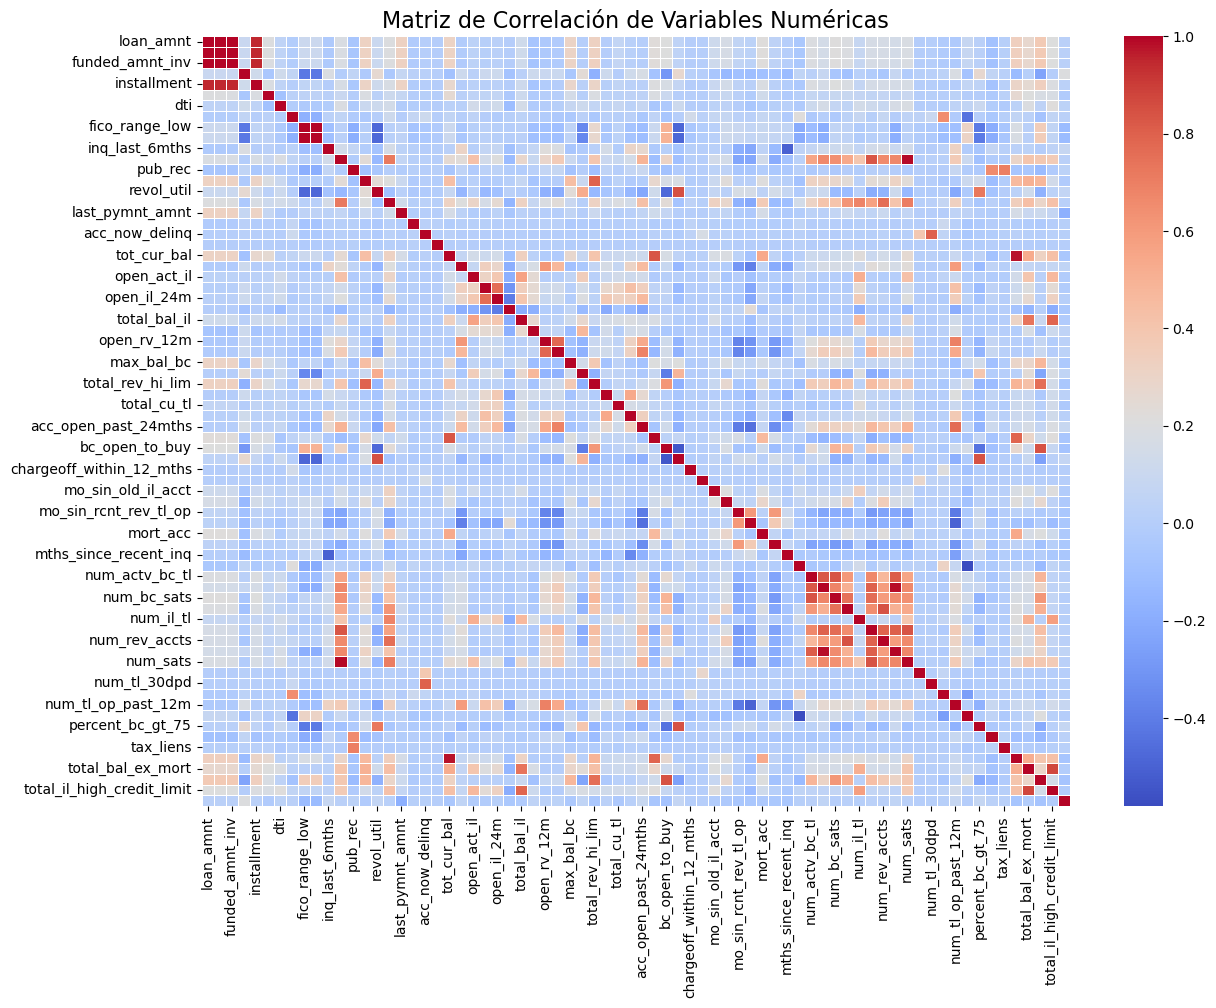

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# columnas numéricas
df_numeric = df_imputed.select_dtypes(include=['float64', 'int64'])

# Matriz de correlación 
corr_matrix = df_numeric.corr()

print("Matriz de correlación (primeras filas):")
print(corr_matrix.head())

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False, fmt=".2f",
            linewidths=0.5, cbar=True)
plt.title("Matriz de Correlación de Variables Numéricas", fontsize=16)
plt.show()
